# Transformer Model 

In [38]:
"""
Imports
"""

from abc import ABC, abstractmethod
import math
import numpy as np
import pandas as pd
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0
CUDA available: False


In [39]:
"""
Base Template for Forecasting Models
"""

class BaseForecastModel(ABC):

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        """Train your model on the training data."""
        pass

    @abstractmethod
    def predict(self, X):
        """Make predictions on new data."""
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        """Evaluate model performance on test data."""
        pass

    @abstractmethod
    def save(self, filepath: str):
        """Save your trained model to a file."""
        pass

    @abstractmethod
    def load(self, filepath: str):
        """Load a previously saved model."""
        pass


print("Base class defined!")

Base class defined!


In [40]:
"""
Transformer Modules
"""

# ─── Positional Encoding ────────────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding added to the input embeddings."""

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 500):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)                       # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )                                                                    # (d_model/2,)
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)                                       # (max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:x.size(1)]
        return self.dropout(x)


# ─── TransformerNet ─────────────────────────────────────────────────────────

class TransformerNet(nn.Module):
    """
    Encoder-only Transformer for time-series regression.

    Architecture:
      1. Linear projection: input_size → d_model
      2. Sinusoidal positional encoding
      3. N × TransformerEncoderLayer (multi-head self-attention + FFN)
      4. Extract last time-step representation → Linear → scalar prediction
    """

    def __init__(
        self,
        input_size: int,
        d_model: int = 64,
        nhead: int = 4,
        num_encoder_layers: int = 2,
        dim_feedforward: int = 256,
        dropout: float = 0.1,
    ):
        super().__init__()
        assert d_model % nhead == 0, "d_model must be divisible by nhead"

        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_encoder_layers
        )

        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = self.input_projection(x)      # → (batch, seq_len, d_model)
        x = self.pos_encoding(x)
        x = self.transformer_encoder(x)   # → (batch, seq_len, d_model)
        x = x[:, -1, :]                   # last time step → (batch, d_model)
        return self.fc(x).squeeze(-1)     # → (batch,)


print("PositionalEncoding and TransformerNet defined!")

PositionalEncoding and TransformerNet defined!


In [41]:
"""
Transformer Forecast Model Implementation
"""

class TransformerForecastModel(BaseForecastModel):
    """
    Encoder-only Transformer for commodity price forecasting.
    Inherits from BaseForecastModel and implements all required methods.
    """

    def __init__(
        self,
        task_type: str = 'regression',
        d_model: int = 64,
        nhead: int = 4,
        num_encoder_layers: int = 2,
        dim_feedforward: int = 256,
        dropout: float = 0.1,
        seq_length: int = 12,
        epochs: int = 100,
        lr: float = 0.001,
        batch_size: int = 32,
    ):
        super().__init__(
            task_type=task_type,
            d_model=d_model, nhead=nhead, num_encoder_layers=num_encoder_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, seq_length=seq_length,
            epochs=epochs, lr=lr, batch_size=batch_size,
        )
        self.d_model = d_model
        self.nhead = nhead
        self.num_encoder_layers = num_encoder_layers
        self.dim_feedforward = dim_feedforward
        self.dropout = dropout
        self.seq_length = seq_length
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size

        self.model = None
        self.feature_scaler = StandardScaler()
        self.target_scaler = StandardScaler()
        self.loss_history = []
        self.is_fitted = False
        self.input_size = None

    # ── helpers ──────────────────────────────────────────────────────────────

    def _create_sequences(self, X, y=None):
        """Sliding-window sequences → (samples, seq_length, features)."""
        X_seqs, y_seqs = [], []
        for i in range(len(X) - self.seq_length):
            X_seqs.append(X[i : i + self.seq_length])
            if y is not None:
                y_seqs.append(y[i + self.seq_length])
        X_tensor = torch.FloatTensor(np.array(X_seqs))
        if y is not None:
            return X_tensor, torch.FloatTensor(np.array(y_seqs))
        return X_tensor

    # ── BaseForecastModel interface ───────────────────────────────────────────

    def fit(self, X_train, y_train):
        """Train the Transformer model."""
        if isinstance(X_train, pd.DataFrame):
            X_train = X_train.values
        if isinstance(y_train, (pd.Series, pd.DataFrame)):
            y_train = y_train.values.ravel()

        X_scaled = self.feature_scaler.fit_transform(X_train)
        y_scaled = self.target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

        X_seq, y_seq = self._create_sequences(X_scaled, y_scaled)
        self.input_size = X_seq.shape[2]
        print(f"Training sequences: {X_seq.shape[0]} samples, "
              f"seq_length={self.seq_length}, features={self.input_size}")

        self.model = TransformerNet(
            input_size=self.input_size,
            d_model=self.d_model,
            nhead=self.nhead,
            num_encoder_layers=self.num_encoder_layers,
            dim_feedforward=self.dim_feedforward,
            dropout=self.dropout,
        )

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.MSELoss()
        dataset = TensorDataset(X_seq, y_seq)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        self.model.train()
        self.loss_history = []
        for epoch in range(self.epochs):
            epoch_loss = 0.0
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                preds = self.model(X_batch)
                loss = criterion(preds, y_batch)
                loss.backward()
                # Gradient clipping helps stabilise Transformer training
                nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                optimizer.step()
                epoch_loss += loss.item() * len(X_batch)
            epoch_loss /= len(dataset)
            self.loss_history.append(epoch_loss)
            if (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1:3d}/{self.epochs}  Loss: {epoch_loss:.6f}")

        self.is_fitted = True
        print(f"Training complete! Final loss: {self.loss_history[-1]:.6f}")

    def predict(self, X):
        """Return predictions. X must have at least seq_length rows."""
        if not self.is_fitted:
            raise ValueError("Model not trained! Call fit() first.")
        if isinstance(X, pd.DataFrame):
            X = X.values

        X_scaled = self.feature_scaler.transform(X)
        X_seq = self._create_sequences(X_scaled)

        self.model.eval()
        with torch.no_grad():
            preds_scaled = self.model(X_seq).numpy()

        return self.target_scaler.inverse_transform(
            preds_scaled.reshape(-1, 1)
        ).ravel()

    def evaluate(self, X_test, y_test):
        """Compute evaluation metrics; aligns predictions with ground truth."""
        predictions = self.predict(X_test)
        if isinstance(y_test, (pd.Series, pd.DataFrame)):
            y_test = y_test.values.ravel()
        y_aligned = y_test[self.seq_length:]
        mse = mean_squared_error(y_aligned, predictions)
        return {
            'mse':  mse,
            'rmse': np.sqrt(mse),
            'mae':  mean_absolute_error(y_aligned, predictions),
            'r2':   r2_score(y_aligned, predictions),
        }

    def save(self, filepath: str):
        """Persist the trained model to disk."""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'state_dict':       self.model.state_dict(),
                'feature_scaler':   self.feature_scaler,
                'target_scaler':    self.target_scaler,
                'input_size':       self.input_size,
                'd_model':          self.d_model,
                'nhead':            self.nhead,
                'num_encoder_layers': self.num_encoder_layers,
                'dim_feedforward':  self.dim_feedforward,
                'dropout':          self.dropout,
                'seq_length':       self.seq_length,
                'loss_history':     self.loss_history,
                'is_fitted':        self.is_fitted,
            }, f)
        print(f"Model saved to {filepath}")

    def load(self, filepath: str):
        """Restore a previously saved model."""
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        self.feature_scaler     = data['feature_scaler']
        self.target_scaler      = data['target_scaler']
        self.input_size         = data['input_size']
        self.d_model            = data['d_model']
        self.nhead              = data['nhead']
        self.num_encoder_layers = data['num_encoder_layers']
        self.dim_feedforward    = data['dim_feedforward']
        self.dropout            = data['dropout']
        self.seq_length         = data['seq_length']
        self.loss_history       = data['loss_history']
        self.is_fitted          = data['is_fitted']
        self.model = TransformerNet(
            input_size=self.input_size,
            d_model=self.d_model,
            nhead=self.nhead,
            num_encoder_layers=self.num_encoder_layers,
            dim_feedforward=self.dim_feedforward,
            dropout=self.dropout,
        )
        self.model.load_state_dict(data['state_dict'])
        self.model.eval()
        print(f"Model loaded from {filepath}")


print("TransformerForecastModel defined!")

TransformerForecastModel defined!


In [42]:
"""
Data Loading Functions
"""

BASE = "/Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models"

def load_fred_md(filepath):
    """Load a single FRED-MD vintage CSV."""
    print(f"Loading FRED-MD from: {filepath}")
    df = pd.read_csv(filepath)
    # First row is transformation codes — skip it
    df = df.iloc[1:].reset_index(drop=True)
    df['sasdate'] = pd.to_datetime(df['sasdate'], errors='coerce')
    df = df.dropna(subset=['sasdate']).set_index('sasdate')
    df.index.name = 'date'
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    # Normalise TWEX column name (older vintages use TWEXMMTH, newer use TWEXAFEGSMTHx)
    df.rename(columns={'TWEXMMTH': 'TWEXAFEGSMTHx'}, inplace=True)
    print(f"  → {df.shape[0]} rows, {df.shape[1]} columns")
    return df


def load_wheat_futures(ticker="ZW=F", start_date="1999-01-01"):
    """Load wheat futures from Yahoo Finance."""
    print(f"Downloading {ticker} from Yahoo Finance...")
    df = yf.download(ticker, start=start_date, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    print(f"  → {df.shape[0]} rows")
    return df


def merge_fred_wheat(fred_df, wheat_df):
    """Merge FRED-MD with monthly wheat prices."""
    wheat_monthly = wheat_df['Close'].resample('ME').last()
    wheat_monthly.name = 'Wheat_Price'
    fred_df.index = fred_df.index.to_period('M')
    wheat_monthly.index = wheat_monthly.index.to_period('M')
    merged = fred_df.join(wheat_monthly.to_frame(), how='inner')
    # Drop columns with >30% missing, forward-fill, drop remaining NaN
    missing_pct = merged.isnull().sum() / len(merged)
    merged = merged.loc[:, missing_pct <= 0.3]
    merged = merged.ffill().dropna()
    print(f"  → Merged: {merged.shape[0]} rows, {merged.shape[1]} columns")
    return merged


# Features specified in Agriculture - Lab Meetings.pdf
# Note: WPSFD49502 (PPI) and VIXCLSx (VIX) excluded — not present in training vintages
# TWEXAFEGSMTHx: older vintages use TWEXMMTH (renamed above in load_fred_md)
SELECTED_FEATURES = [
    'RPI',              # Real Personal Income
    'DPCERA3M086SBEA',  # Real Personal Consumption Expenditures
    'RETAILx',          # Retail and Food Services Sales
    'INDPRO',           # Industrial Production Index
    'NDMANEMP',         # Employment: Nondurable Goods
    'ACOGNO',           # New Orders: Consumer Goods
    'BUSINVx',          # Total Business Inventories
    'BUSLOANS',         # Commercial & Industrial Loans
    'S&P 500',          # S&P 500 Stock Index
    'FEDFUNDS',         # Federal Funds Rate
    'GS10',             # 10-Year Treasury Rate
    'TWEXAFEGSMTHx',    # Trade Weighted USD Index
    'CUSR0000SAC',      # CPI: Commodities
    'DNDGRG3M086SBEA',  # PCE: Nondurable Goods Deflator
    'CES0600000008',    # Avg Hourly Earnings: Goods-Producing
    'UMCSENTx',         # Consumer Sentiment Index
    'DTCTHFNM',         # Total Consumer Loans and Leases
    'Wheat_Price',      # Target
]


def select_features(df, features=SELECTED_FEATURES):
    """Select subset of variables and drop any missing."""
    available = [f for f in features if f in df.columns]
    missing = [f for f in features if f not in df.columns]
    if missing:
        print(f"  Warning — columns not found (skipped): {missing}")
    out = df[available].dropna()
    print(f"  → Selected {len(available)} variables, {len(out)} observations")
    return out


print("Data functions defined!")

Data functions defined!


In [43]:
# ============================================================================
# Load Data — Train / Validation / Test
# ============================================================================

# Wheat futures (shared across all splits)
wheat_df = load_wheat_futures("ZW=F")

# --- TRAINING: 1999-08 to 2014-12 (document-specified range) ---
print("\n--- TRAINING DATA ---")
train_fred = load_fred_md(f"{BASE}/Historical FRED-MD Vintages Final/2014-12.csv")
train_merged = merge_fred_wheat(train_fred, wheat_df)
train_data = select_features(train_merged)
train_data = train_data.loc['1999-08':'2014-12']  # Restrict to document-specified range
print(f"  → After date filter (1999-08 – 2014-12): {len(train_data)} observations")

# --- VALIDATION: 2015-01 to 2024-12 ---
print("\n--- VALIDATION DATA ---")
val_fred = load_fred_md(f"{BASE}/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/FRED-MD_2024m12.csv")
val_merged = merge_fred_wheat(val_fred, wheat_df)
val_data = select_features(val_merged)
val_data = val_data[val_data.index > train_data.index[-1]]

# --- TEST: 2026-01-MD.csv ---
print("\n--- TEST DATA ---")
test_fred = load_fred_md(f"{BASE}/2026-01-MD.csv")
test_merged = merge_fred_wheat(test_fred, wheat_df)
test_data = select_features(test_merged)
test_data = test_data[test_data.index > val_data.index[-1]]

print(f"\nFinal split sizes — Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# Separate features and target
target = 'Wheat_Price'
feature_cols = [c for c in train_data.columns if c != target]

X_train, y_train = train_data[feature_cols], train_data[target]
X_val, y_val = val_data[feature_cols], val_data[target]
X_test, y_test = test_data[feature_cols], test_data[target]

print(f"Features: {feature_cols}")
train_data.head()

  → 6419 rows

--- TRAINING DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/Historical FRED-MD Vintages Final/2014-12.csv
  → 671 rows, 126 columns
  → Merged: 173 rows, 127 columns
  → Selected 18 variables, 173 observations
  → After date filter (1999-08 – 2014-12): 173 observations

--- VALIDATION DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/FRED-MD_2024m12.csv
  → 791 rows, 126 columns
  → Merged: 293 rows, 127 columns
  → Selected 18 variables, 293 observations

--- TEST DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/2026-01-MD.csv
  → 804 rows, 126 columns
  → Merged: 306 rows, 127 col

,RPI,DPCERA3M086SBEA,RETAILx,INDPRO,NDMANEMP,ACOGNO,BUSINVx,BUSLOANS,S&P 500,FEDFUNDS,GS10,TWEXAFEGSMTHx,CUSR0000SAC,DNDGRG3M086SBEA,CES0600000008,UMCSENTx,DTCTHFNM,Wheat_Price
date,,,,,,,,,,,,,,,,,,
2000-07,10427.5,82.874,272638.0,92.6345,6393.0,125011.0,1175302.0,1068.6,1473.00,6.54,6.05,101.00,149.8,83.103,15.26,108.3,449083.0,246.0
2000-08,10477.3,83.313,272954.0,92.3191,6375.0,122095.0,1183156.0,1071.6,1485.46,6.50,5.83,102.55,149.2,82.677,15.32,107.3,456248.0,251.0
2000-09,10476.5,83.979,277523.0,92.6699,6356.0,126682.0,1183391.0,1072.9,1468.05,6.52,5.80,104.27,150.4,83.481,15.37,106.8,466633.0,258.0
2000-10,10492.2,83.943,276973.0,92.3486,6343.0,126059.0,1189984.0,1078.2,1390.14,6.51,5.74,105.88,150.1,83.272,15.45,105.8,484040.0,253.5
2000-11,10489.0,84.011,275928.0,92.3421,6323.0,126212.0,1197083.0,1080.4,1378.04,6.51,5.72,106.76,150.3,83.402,15.50,107.6,490228.0,252.5


In [44]:
# ============================================================================
# Train Transformer Model
# ============================================================================

model = TransformerForecastModel(
    task_type='regression',
    d_model=64,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=256,
    dropout=0.1,
    seq_length=12,
    epochs=100,
    lr=0.001,
    batch_size=32,
)

model.fit(X_train, y_train)

Training sequences: 161 samples, seq_length=12, features=17
  Epoch  20/100  Loss: 0.102223
  Epoch  40/100  Loss: 0.083335
  Epoch  60/100  Loss: 0.065822
  Epoch  80/100  Loss: 0.049293
  Epoch 100/100  Loss: 0.036550
Training complete! Final loss: 0.036550


In [45]:
# ============================================================================
# Evaluate Model
# ============================================================================

# For validation: concatenate train + val so the model has seq_length history
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Predict over the full train+val range, then slice out validation predictions
preds_all = model.predict(X_train_val)
# preds_all aligns with y_train_val starting at index seq_length
# We want predictions for the validation portion
val_start_idx = len(X_train) - model.seq_length  # offset in preds_all
val_preds = preds_all[val_start_idx:]
val_actual = y_train_val.values[model.seq_length + val_start_idx:]

mse = mean_squared_error(val_actual, val_preds)
print("=" * 40)
print("VALIDATION SET PERFORMANCE")
print("=" * 40)
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {np.sqrt(mse):.4f}")
print(f"  MAE:  {mean_absolute_error(val_actual, val_preds):.4f}")
print(f"  R2:   {r2_score(val_actual, val_preds):.4f}")

# Test evaluation (concatenate train + val + test)
if len(X_test) > 0:
    X_full = pd.concat([X_train, X_val, X_test])
    y_full = pd.concat([y_train, y_val, y_test])
    preds_full = model.predict(X_full)
    test_start_idx = len(X_train) + len(X_val) - model.seq_length
    test_preds = preds_full[test_start_idx:]
    test_actual = y_full.values[model.seq_length + test_start_idx:]

    mse_t = mean_squared_error(test_actual, test_preds)
    print("\n" + "=" * 40)
    print("TEST SET PERFORMANCE")
    print("=" * 40)
    print(f"  MSE:  {mse_t:.4f}")
    print(f"  RMSE: {np.sqrt(mse_t):.4f}")
    print(f"  MAE:  {mean_absolute_error(test_actual, test_preds):.4f}")
    print(f"  R2:   {r2_score(test_actual, test_preds):.4f}")
else:
    print("\nNo test data available.")

VALIDATION SET PERFORMANCE
  MSE:  24367.1803
  RMSE: 156.0999
  MAE:  107.7437
  R2:   -0.1941

TEST SET PERFORMANCE
  MSE:  1179.5759
  RMSE: 34.3450
  MAE:  30.2876
  R2:   -4.1951


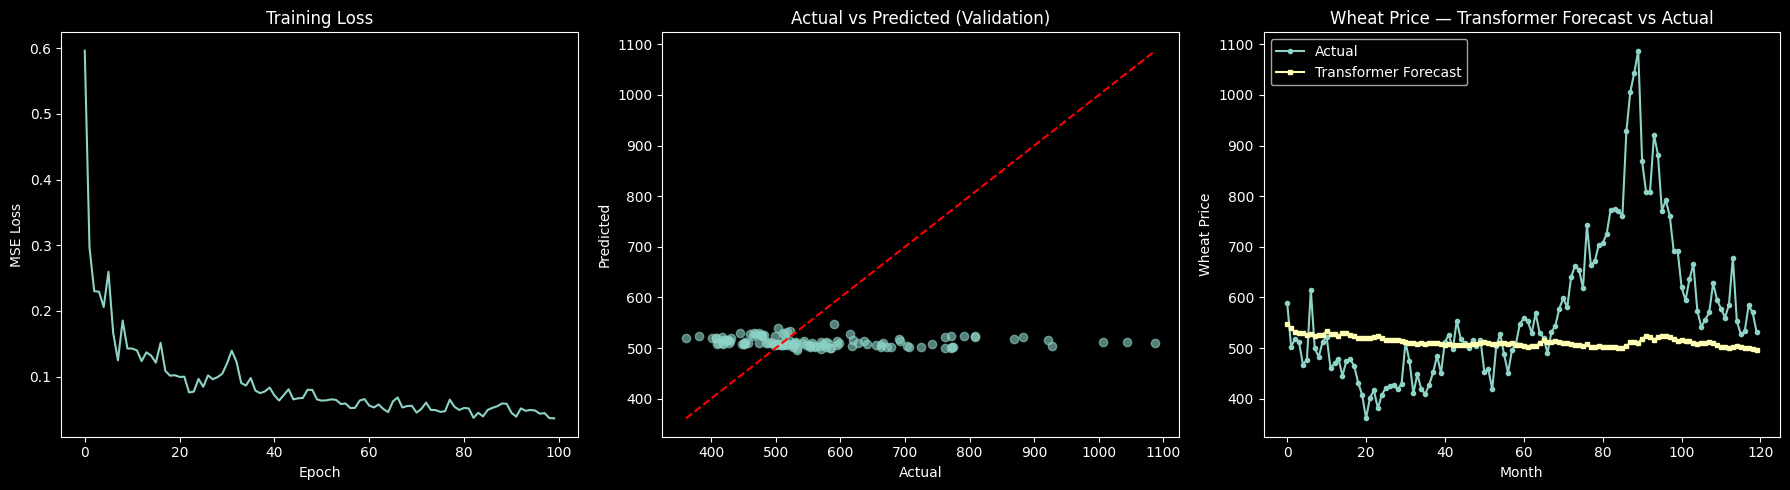

In [46]:
# ============================================================================
# Plot Results
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Training loss curve
axes[0].plot(model.loss_history)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')

# 2. Actual vs Predicted scatter (validation)
axes[1].scatter(val_actual, val_preds, alpha=0.6)
mn, mx = min(val_actual.min(), val_preds.min()), max(val_actual.max(), val_preds.max())
axes[1].plot([mn, mx], [mn, mx], 'r--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted (Validation)')

# 3. Time series comparison (validation)
axes[2].plot(range(len(val_actual)), val_actual, label='Actual', marker='o', markersize=3)
axes[2].plot(range(len(val_preds)), val_preds, label='Transformer Forecast', marker='s', markersize=3)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Wheat Price')
axes[2].set_title('Wheat Price — Transformer Forecast vs Actual')
axes[2].legend()

plt.tight_layout()
plt.show()

In [47]:
# ============================================================================
# Save and Load Model
# ============================================================================

model.save('transformer_wheat_model.pkl')

# Load and verify
new_model = TransformerForecastModel()
new_model.load('transformer_wheat_model.pkl')

# Verify predictions match
preds_orig = model.predict(X_train_val)
preds_loaded = new_model.predict(X_train_val)
print(f"\nLoaded model matches: {np.allclose(preds_orig, preds_loaded)}")

Model saved to transformer_wheat_model.pkl
Model loaded from transformer_wheat_model.pkl

Loaded model matches: True


## Summary

This notebook implements an **encoder-only Transformer** neural network for wheat futures price forecasting:

1. **Data Sources**: FRED-MD macroeconomic indicators + Yahoo Finance wheat futures (ZW=F)
2. **Data Splits**:
   - **Train**: FRED-MD Historical Vintages up to 2014-12
   - **Validation**: FRED-MD Historical Vintages 2015-01 to 2024-12
   - **Test**: 2026-01-MD.csv
3. **Model**: `TransformerForecastModel` inheriting from `BaseForecastModel`
4. **Methods Implemented**: `fit()`, `predict()`, `evaluate()`, `save()`, `load()`

### Architecture
- **Input projection**: Linear layer mapping 8 macro features → d_model (64)
- **Positional encoding**: Sinusoidal encoding to inject sequence order (Transformers have no inherent sense of position)
- **Transformer encoder**: 2 × `TransformerEncoderLayer` with multi-head self-attention (4 heads) and a 256-dimensional feed-forward sub-layer
- **Output head**: Last time-step representation → Linear → scalar wheat price prediction
- **Training stabiliser**: Gradient clipping (max_norm=1.0) to prevent exploding gradients

### Methodology
- Same macro feature subset as VAR/GRU (INDPRO, UNRATE, CPIAUCSL, FEDFUNDS, M2SL, TB3MS, S&P 500, EXUSUKx) for comparability
- StandardScaler applied to features and target
- Sliding window of 12 months creates sequential input for the Transformer
- Adam optimizer with MSE loss

### Key Differences vs GRU
| Aspect | GRU | Transformer |
|---|---|---|
| Sequence processing | Sequential (recurrent) | Parallel (attention) |
| Position awareness | Implicit (order of hidden state updates) | Explicit (sinusoidal positional encoding) |
| Long-range dependencies | Can struggle with very long sequences | Handles via global self-attention |
| Training speed | Slower (sequential) | Faster (parallelisable) |

### Limitations
- Small dataset (173 training samples) limits the expressiveness of self-attention
- d_model must be divisible by nhead (64 / 4 = 16 ✓)
- Less interpretable than VAR or Decision Tree models